In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ast

matrix = pd.read_csv("prs_incrementalr2_matrix_260225_loinccode.csv")
matrix.columns = matrix.columns.str.replace("_hmPOS_GRCh38", "", regex=False)
icd_info = pd.read_csv("../../reference_data/LOINC.csv")
pgs_map = pd.read_csv("../../measurement_preprocess/pgs_id_list_260225.csv") 
icd_pgs_map = pd.read_csv("../../disease_preprocess/pgs_id_list_binary_combined.csv") 

### Basic Info

In [4]:
# basic information of raw result

# select information
target_icd_list = []
target_pgs_list = []
for idx, row in pgs_map.iterrows():
    pgs_ids = ast.literal_eval(row['pgs_ids'])
    target_icd_list.append(row['loinc'])
    target_pgs_list.extend(pgs_ids)

# calculate information
calc_icd_list = matrix["trait"]
calc_pgs_list = matrix.columns.drop("trait").tolist()

print("Number of target Traits (Loinc code):", len(set(target_icd_list)))
print("Number of target PGS (PGS ids):", len(set(target_pgs_list)))
print("Number of calculated Traits (Loinc code):", len(calc_icd_list))
print("Number of calculated PGS (PGS ids):", len(calc_pgs_list))

Number of target Traits (Loinc code): 38
Number of target PGS (PGS ids): 1144
Number of calculated Traits (Loinc code): 37
Number of calculated PGS (PGS ids): 3196


### QC

In [5]:
# filter case number bigger than 200
print("Before filter:", matrix.shape, len(matrix["trait"]))

trait_case_count = pd.read_csv("trait_case_count_260225_loinccode.csv").drop_duplicates("loinc_code")

# merge case count
matrix_merged = matrix.merge(trait_case_count, left_on="trait", right_on="loinc_code", how="left")

# list of include and exclude trait
included_traits = matrix_merged.loc[
    matrix_merged["case_count"] >= 200, "trait"
].tolist()

excluded_traits = matrix_merged.loc[
    matrix_merged["case_count"] < 200, "trait"
].tolist()

print("Included trait number:", len(included_traits))
print("Excluded trait number:", len(excluded_traits))
print("Excluded trait:", excluded_traits)

# filter
matrix = matrix_merged[matrix_merged["case_count"] >= 200]
matrix = matrix.drop(columns=["loinc_code", "case_count"])

print("After filter:", matrix.shape, len(matrix["trait"]))

Before filter: (37, 3197) 37
Included trait number: 36
Excluded trait number: 1
Excluded trait: ['32207-3']
After filter: (36, 3198) 36


In [6]:
# generate a mapping between pgs id and icd id, change colname, set trait information as index
from collections import defaultdict
print("Before filter:", matrix.shape)

# get mapping between PGS id and icd code
pgs2icds = defaultdict(set)
for idx, row in pgs_map.iterrows():
    pgs_ids = ast.literal_eval(row['pgs_ids'])
    icd_code = row['loinc']

    for pgs in pgs_ids:
        pgs2icds[pgs].add(icd_code)

for idx, row in icd_pgs_map.iterrows():
    pgs_ids = ast.literal_eval(row['pgs_ids'])
    icd_code = row['icd']

    for pgs in pgs_ids:
        pgs2icds[pgs].add(icd_code)

# rename each col
matrix = matrix.set_index("trait")
new_columns = []
for col in matrix.columns:
    if col in pgs2icds:
        icd_list = "+".join(pgs2icds[col])
        new_columns.append(f"{icd_list}__{col}")
    else:
        new_columns.append(f"NA__{col}")

matrix.columns = new_columns
print("After filter:", matrix.shape)

Before filter: (36, 3198)
After filter: (36, 3197)


In [7]:
# check how many pgs for each trait is calculated
matrix_df = matrix.copy()
prs_count = {}

for trait in matrix_df.index:
    count = 0
    
    for col in matrix_df.columns:
        if "__" not in col:
            continue
        
        icd_part = col.split("__")[0]      # C44+C43
        icd_list = icd_part.split("+")     # ["C44","C43"]

        if trait in icd_list:
            count += 1

    prs_count[trait] = count

prs_count_df = pd.DataFrame.from_dict(
    prs_count,
    orient="index",
    columns=["calc_prs_count"]
)

prs_count_df = prs_count_df.reset_index()
prs_count_df = prs_count_df.rename(columns={"index": "loinc"})

In [8]:
# save data after QC
result = pgs_map.merge(prs_count_df, on="loinc")
result["include_in_analysis"] = result["loinc"].isin(included_traits).astype("int8")
result = result.merge(
    trait_case_count[["loinc_code", "case_count"]],
    left_on="loinc",
    right_on="loinc_code",
    how="left"
).rename(columns={"case_count": "case_num"})
result = result.drop(columns=["pgs_urls", "loinc_code"])
result.to_csv("prs_incrementalr2_metadata_260225_loinccode.csv", index=False)
matrix.to_csv("prs_incrementalr2_matrix_260225_loinccode_qc.csv", index=True)
print("Data shape after QC:", matrix.shape)

Data shape after QC: (36, 3197)


### Save Rank Matrix

In [9]:
import numpy as np
matrix = pd.read_csv("prs_incrementalr2_matrix_260225_loinccode_qc.csv")
matrix = matrix.set_index("trait")
matrix = matrix.apply(pd.to_numeric, errors='coerce') 

# check how many pgs for each trait is calculated
matrix_df = matrix.copy()
prs_count = {}

for trait in matrix_df.index:
    count = 0
    
    for col in matrix_df.columns:
        if "__" not in col:
            continue
        
        icd_part = col.split("__")[0]      # C44+C43
        icd_list = icd_part.split("+")     # ["C44","C43"]

        if trait in icd_list:
            count += 1

    prs_count[trait] = count

prs_count_df = pd.DataFrame.from_dict(
    prs_count,
    orient="index",
    columns=["calc_prs_count"]
)

prs_count_df = prs_count_df.reset_index()
prs_count_df = prs_count_df.rename(columns={"index": "loinc"})

# save ranking matrix 
rank_rows = []
for trait in matrix_df.index: 
    row = matrix_df.loc[trait].sort_values(ascending=False) 
    rank_rows.append(row.index.tolist())
rank_df = pd.DataFrame(
    rank_rows,
    index=matrix_df.index,
    columns=[f"rank_{i+1}" for i in range(matrix_df.shape[1])]
)
rank_df.to_csv("prs_incrementalr2_matrix_260225_loinccode_rankmatrix.csv", index=True)

In [10]:
# save rank matrix: each row only ranks its own PGS (self-PGS only)
self_rank_rows = []
self_rank_counts = []

for trait in matrix_df.index:
    # filter to columns whose ICD part contains this trait
    self_cols = [
        col for col in matrix_df.columns
        if "__" in col and trait in col.split("__")[0].split("+")
    ]
    if self_cols:
        row = matrix_df.loc[trait, self_cols].sort_values(ascending=False)
        self_rank_rows.append(row.index.tolist())
        self_rank_counts.append(len(self_cols))
    else:
        self_rank_rows.append([])
        self_rank_counts.append(0)

max_self_pgs = max(self_rank_counts)
padded = [r + [None] * (max_self_pgs - len(r)) for r in self_rank_rows]

self_rank_df = pd.DataFrame(
    padded,
    index=matrix_df.index,
    columns=[f"rank_{i+1}" for i in range(max_self_pgs)]
)
self_rank_df.to_csv("prs_incrementalr2_matrix_260225_loinccode_selfrankmatrix.csv", index=True)
print("Self-PGS rank matrix shape:", self_rank_df.shape)
print(self_rank_df.head())

Self-PGS rank matrix shape: (36, 227)
                     rank_1              rank_2              rank_3  \
trait                                                                 
10835-7  10835-7__PGS004202  10835-7__PGS004201  10835-7__PGS004205   
18262-6  18262-6__PGS004649  18262-6__PGS004639  18262-6__PGS004651   
1869-7    1869-7__PGS001888   1869-7__PGS002101   1869-7__PGS000671   
1884-6    1884-6__PGS003492   1884-6__PGS000672   1884-6__PGS002102   
2085-9    2085-9__PGS004100   2085-9__PGS004086   2085-9__PGS003780   

                     rank_4              rank_5              rank_6  \
trait                                                                 
10835-7  10835-7__PGS004203  10835-7__PGS004204  10835-7__PGS000313   
18262-6  18262-6__PGS002654  18262-6__PGS002337  18262-6__PGS004650   
1869-7                 None                None                None   
1884-6    1884-6__PGS001889                None                None   
2085-9    2085-9__PGS004043   2085-9__

### Overall Performance

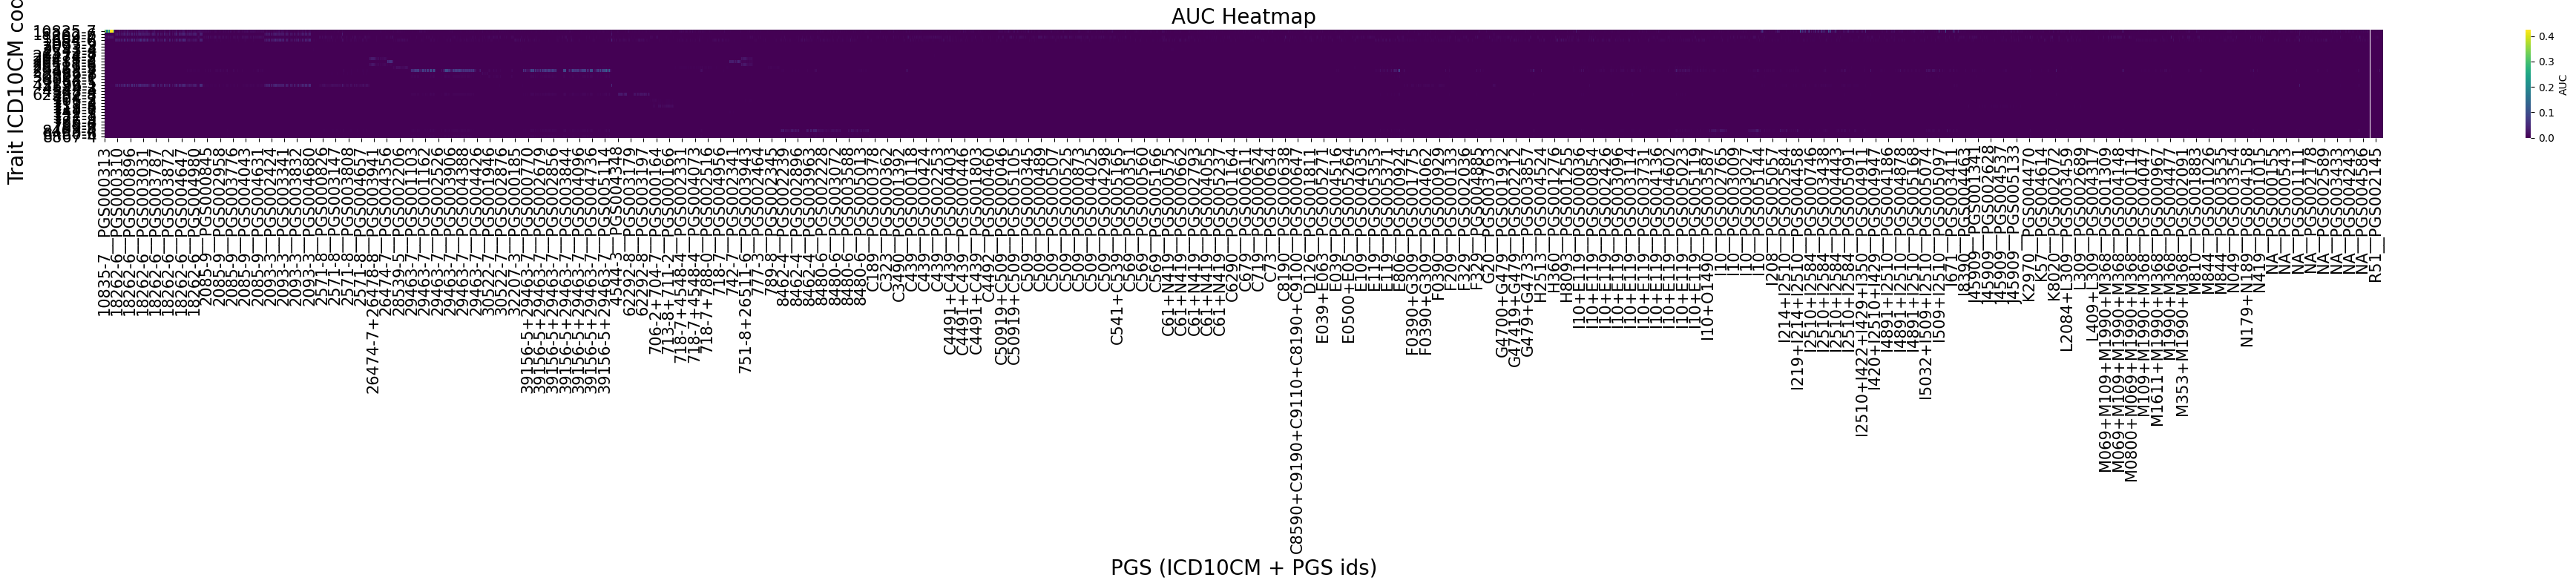

In [11]:
matrix_df = matrix.copy()
matrix_df = matrix_df.sort_index(axis=0)  # 按 trait 排序
matrix_df = matrix_df.sort_index(axis=1)  # 按 ICD / PGS 排序

plt.figure(figsize=(40, 8))
sns.heatmap(matrix_df, cmap="viridis", cbar_kws={'label': 'AUC'})
plt.xlabel("PGS (ICD10CM + PGS ids)", fontsize=20)
plt.ylabel("Trait ICD10CM code", fontsize=20)
plt.title("AUC Heatmap", fontsize=20)
plt.xticks(rotation=90, fontsize=15)
plt.yticks(fontsize=15)
plt.tight_layout()
plt.show()

In [12]:
top_n = 5
top_n_prs_df = {}

for trait in matrix_df.index:
    top_prs = matrix_df.loc[trait].sort_values(ascending=False).head(top_n)
    top_n_prs_df[trait] = top_prs

best_prs = matrix_df.idxmax(axis=1)
best_auc = matrix_df.max(axis=1)

top_prs_df = pd.DataFrame({
    "trait": matrix_df.index,
    "best_prs": best_prs.values,
    "best_auc": best_auc.values
})

print(top_prs_df)

      trait                    best_prs  best_auc
0   10835-7          10835-7__PGS004202  0.424368
1   18262-6          18262-6__PGS004649  0.046121
2    1869-7       M1990+M368__PGS004547  0.028918
3    1884-6          18262-6__PGS002703  0.059508
4    2085-9           8462-4__PGS002239  0.000154
5    2093-3           8462-4__PGS002239  0.000158
6    2243-4           2243-4__PGS002916  0.002454
7    2571-8           8462-4__PGS002239  0.000153
8   26474-7             C439__PGS000745  0.001700
9   26478-8  26474-7+26478-8__PGS003557  0.031294
10  26485-3    26485-3+742-7__PGS000103  0.061159
11  26511-6    751-8+26511-6__PGS002214  0.027413
12  28539-5          28539-5__PGS000099  0.016272
13  29463-7  39156-5+29463-7__PGS005199  0.136278
14   2986-8           2986-8__PGS003559  0.012353
15  30522-7          30522-7__PGS001946  0.006384
16   3084-1           2243-4__PGS002919  0.000616
17  39156-5  39156-5+29463-7__PGS002679  0.000722
18  43396-1          18262-6__PGS002337  0.054635


### Avg PRS Performance

In [13]:
matrix_df = matrix.copy()
icd_part = [col.split("__")[0] for col in matrix_df.columns]
pgs_part = [col.split("__")[1] for col in matrix_df.columns]

icd_to_cols = defaultdict(list)
for col, icd_string in zip(matrix_df.columns, icd_part):
    icds = icd_string.split("+")
    for icd in icds:
        icd_to_cols[icd].append(col)
        
icd_avg_series = {}
for icd, cols in icd_to_cols.items():
    icd_avg_series[icd] = matrix_df[cols].mean(axis=1)
icd_avg_df = pd.concat(icd_avg_series, axis=1)

common = icd_avg_df.index.intersection(icd_avg_df.columns)
square_matrix = icd_avg_df.loc[common, common]
print(square_matrix.shape)

(36, 36)


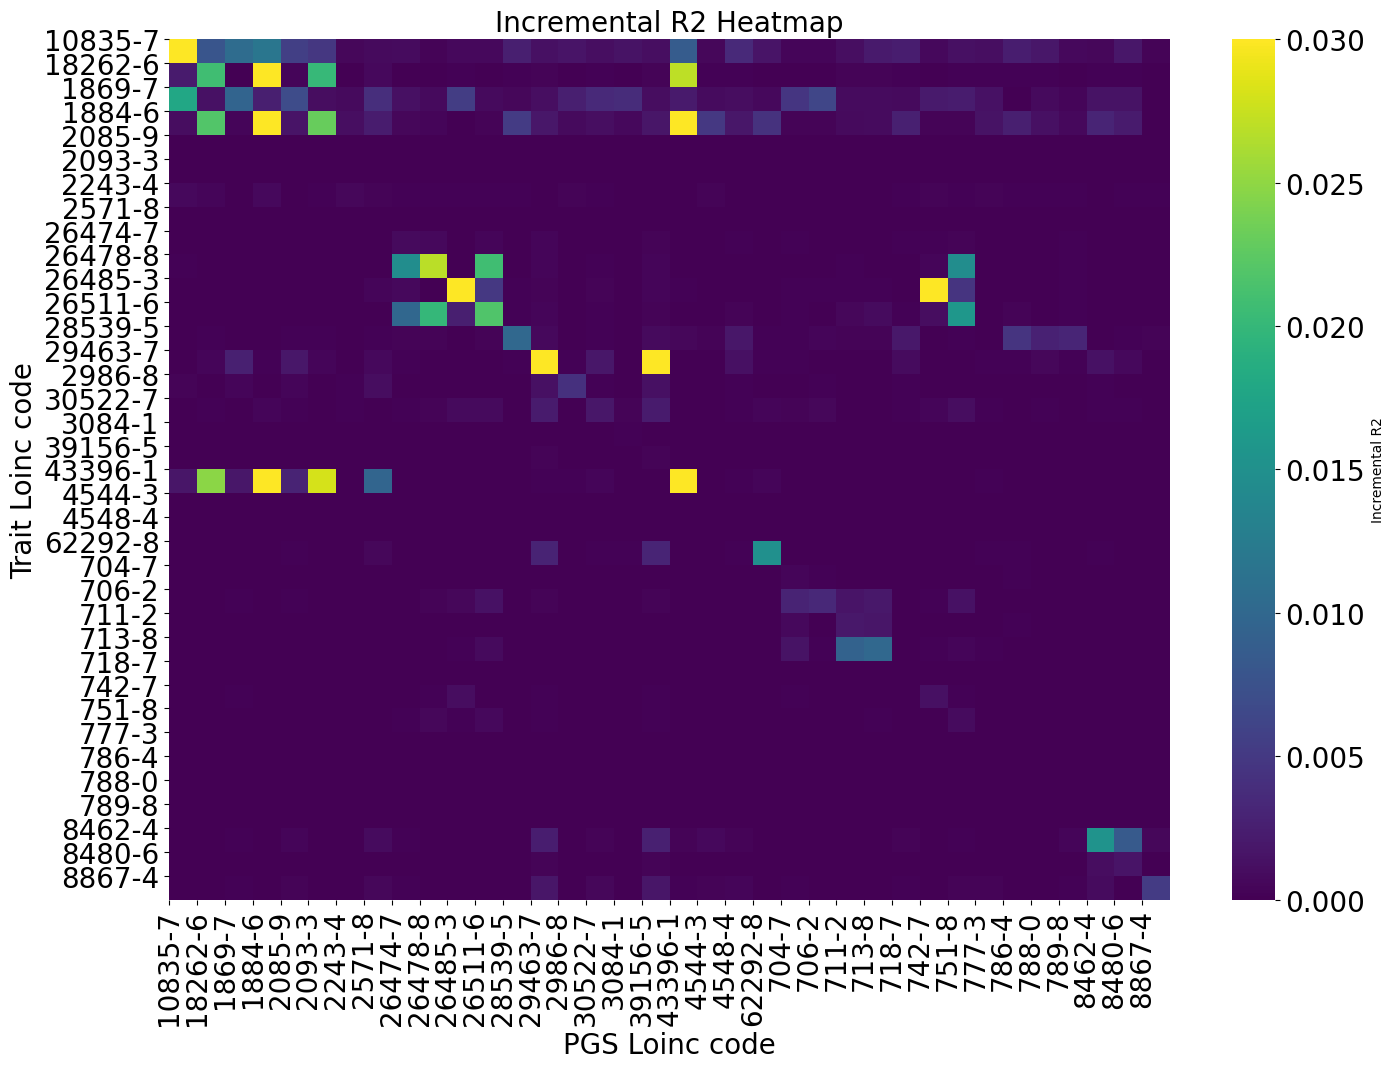

In [14]:
square_matrix = square_matrix.sort_index(axis=0)  # 按 trait 排序
square_matrix = square_matrix.sort_index(axis=1)  # 按 ICD / PGS 排序

plt.figure(figsize=(len(square_matrix) * 0.4, len(square_matrix) * 0.3))
ax = sns.heatmap(
    square_matrix,
    cmap="viridis",
    cbar_kws={'label': 'Incremental R2'},
    vmax=0.03,
    vmin=0.00
)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=20) 
plt.xlabel("PGS Loinc code", fontsize=20)
plt.ylabel("Trait Loinc code", fontsize=20)
plt.title("Incremental R2 Heatmap", fontsize=20)
ax.set_yticks(range(len(square_matrix.index)))
ax.set_yticklabels(square_matrix.index, fontsize=20)
ax.set_xticks(range(len(square_matrix.columns)))
ax.set_xticklabels(square_matrix.columns, rotation=90, fontsize=20)
plt.tight_layout()
plt.show()

### Top50 PRS Normalized to the Best

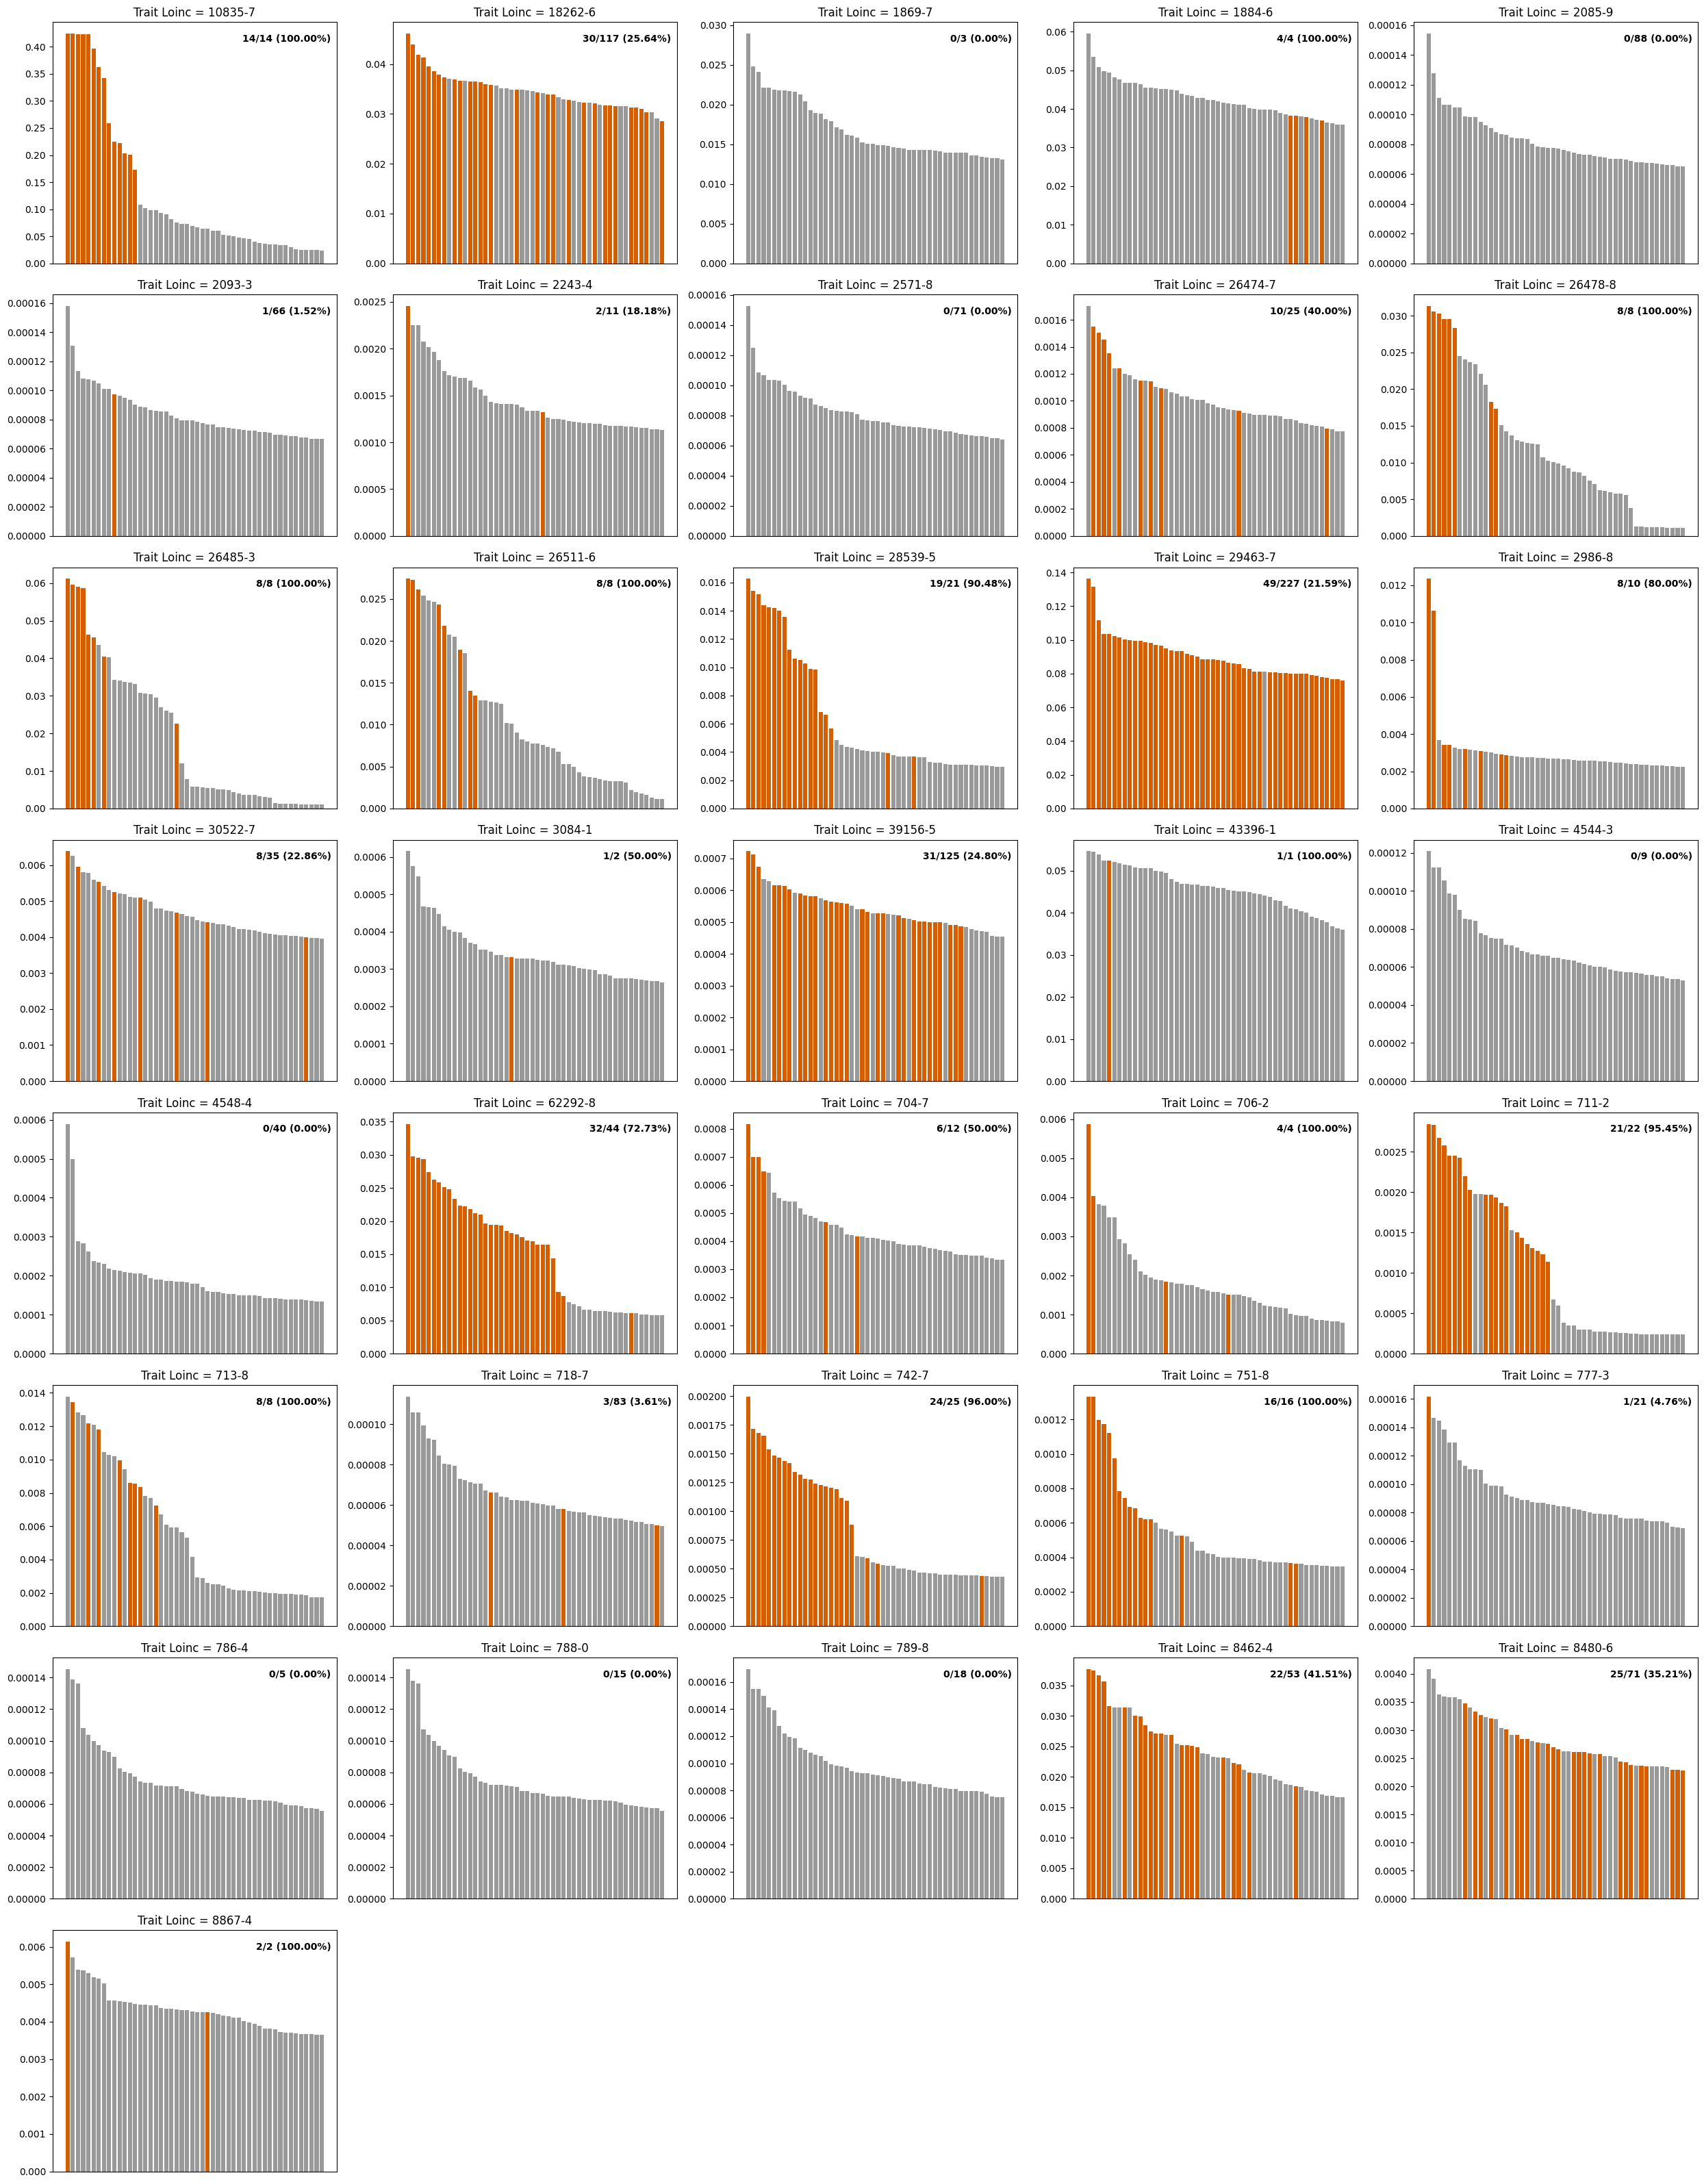

In [15]:
import numpy as np
import math

matrix_df = matrix.copy()
normalized = matrix_df.div(matrix_df.max(axis=1), axis=0)
normalized = matrix_df
top_n = 50

rank_matrix = []
for trait in normalized.index:
    row = normalized.loc[trait].sort_values(ascending=False).head(top_n)
    rank_matrix.append(row.values)
rank_matrix = np.array(rank_matrix)  
# mean_rank_curve = rank_matrix.mean(axis=0)

traits = normalized.index
n_traits = len(traits)

# 每行 5 个
n_cols = 5
n_rows = math.ceil(n_traits / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for i, trait in enumerate(traits):

    ax = axes[i]

    row = normalized.loc[trait].sort_values(ascending=False).head(top_n)

    colors = [
        "#D55E00"
        if trait in col.split("__")[0].split("+")
        else "#999999"
        for col in row.index
    ]
    ax.bar(range(len(row)), row.values, color=colors)
    
    ax.set_title(f"Trait Loinc = {trait}", fontsize=12)
    ax.set_xticks([])

    total_self_prs = prs_count_df[
        prs_count_df["loinc"] == trait
    ]["calc_prs_count"].iloc[0]

    top_self_prs = sum(
        trait in col.split("__")[0].split("+")
        for col in row.index
    )

    ratio = top_self_prs / total_self_prs if total_self_prs > 0 else 0

    ax.text(
        0.98, 0.95,
        f"{top_self_prs}/{total_self_prs} ({ratio:.2%})",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        fontweight="bold"
    )

# delete vacant subplot
for j in range(n_traits, len(axes)):
    fig.delaxes(axes[j])

plt.savefig(
    "cross_trait_enrichment_loinc_260225.pdf",
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()

### Jaccard Index

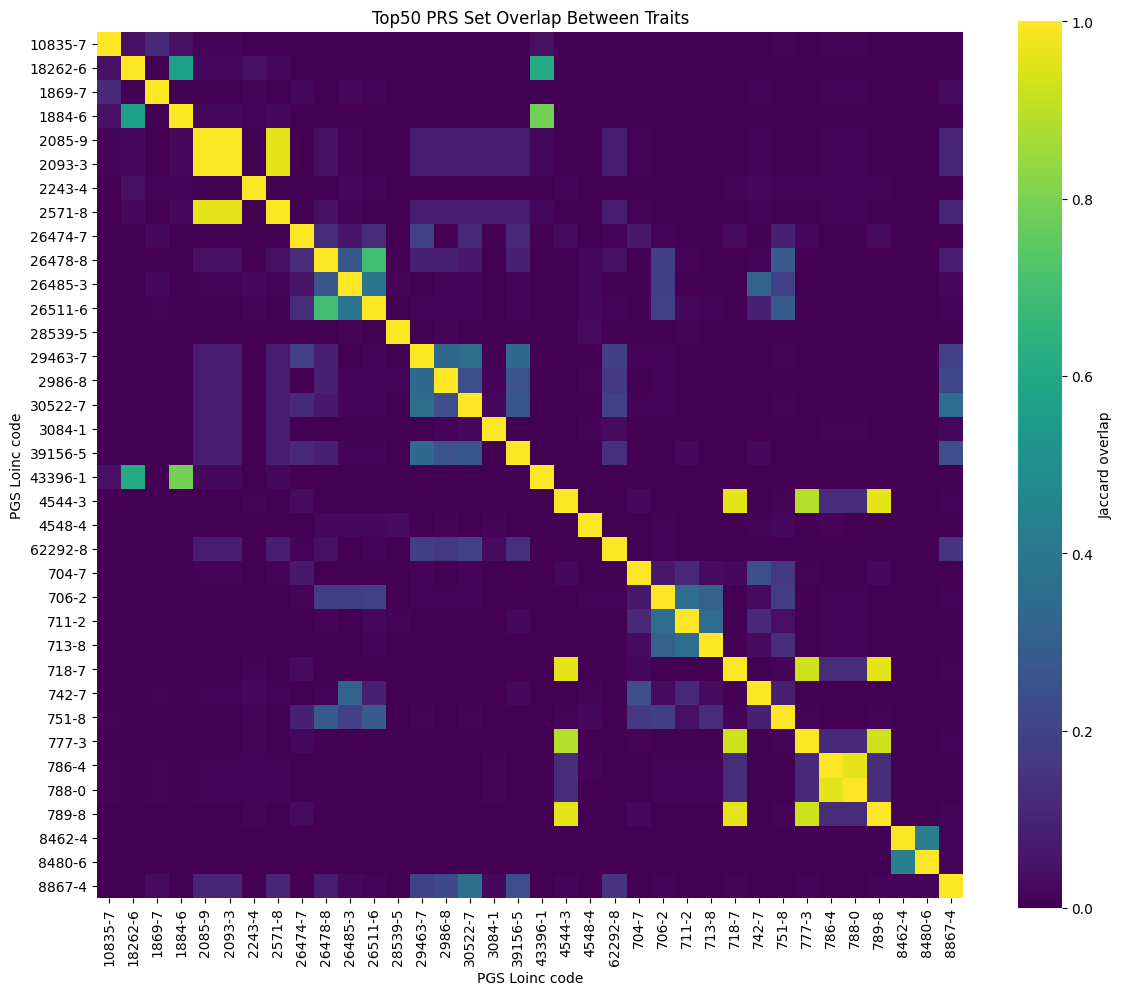

In [16]:
matrix_df = matrix.copy()
normalized = matrix_df.div(matrix_df.max(axis=1), axis=0)
top_n = 50
traits = normalized.index  # 如果超过25个，只取前25个

top_sets = {}
for trait in traits:
    row = normalized.loc[trait].sort_values(ascending=False).head(top_n)
    top_sets[trait] = set(row.index)

n = len(traits)
overlap_matrix = pd.DataFrame(
    np.zeros((n, n)),
    index=traits,
    columns=traits
)

for i, trait_i in enumerate(traits):
    for j, trait_j in enumerate(traits):
        
        set_i = top_sets[trait_i]
        set_j = top_sets[trait_j]
        
        intersection = len(set_i & set_j)
        union = len(set_i | set_j)
        
        jaccard = intersection / union if union > 0 else 0
        
        overlap_matrix.loc[trait_i, trait_j] = jaccard

plt.figure(figsize=(12, 10))
sns.heatmap(
    overlap_matrix,
    cmap="viridis",
    vmin=0,
    vmax=1,
    square=True,
    cbar_kws={"label": "Jaccard overlap"}
)
plt.title("Top50 PRS Set Overlap Between Traits")
plt.xlabel("PGS Loinc code")
plt.ylabel("PGS Loinc code")
plt.tight_layout()
plt.show()


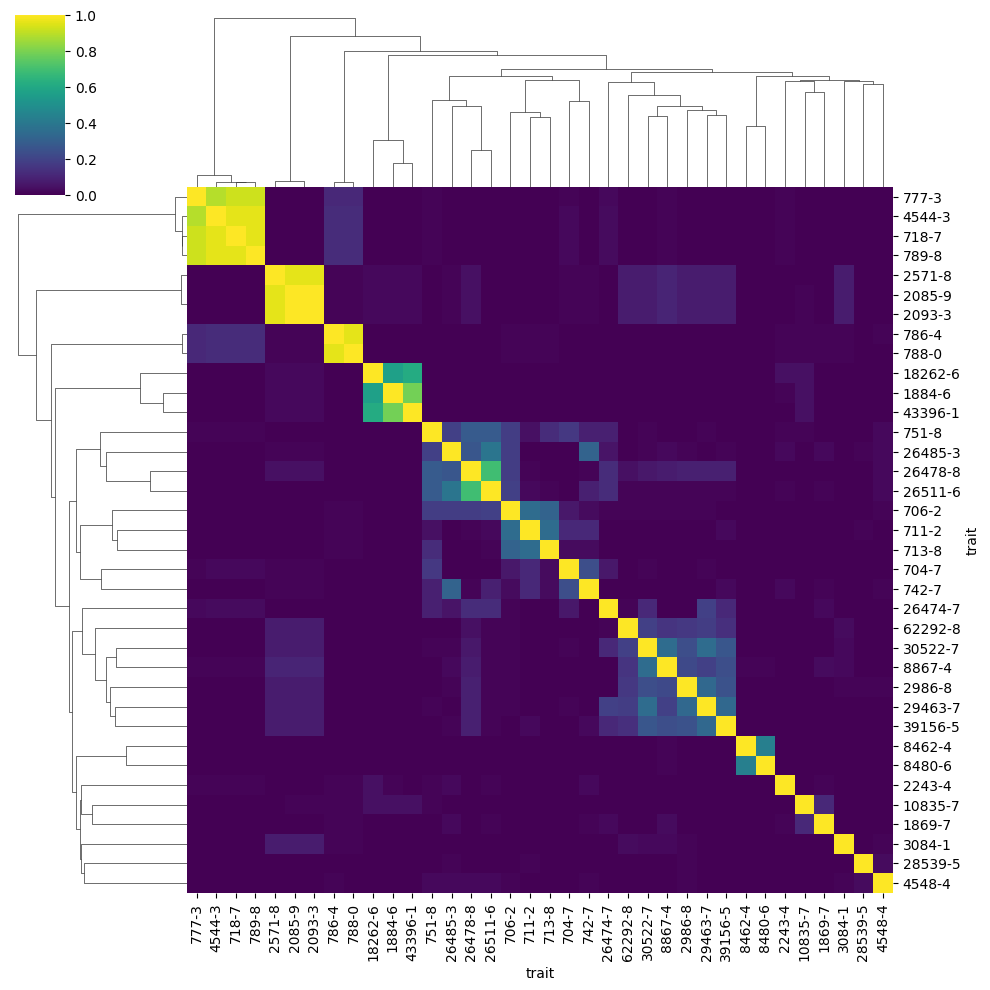

In [17]:
sns.clustermap(overlap_matrix, cmap="viridis")

In [18]:
mean_overlap = overlap_matrix.mean(axis=1)
mean_overlap = mean_overlap.sort_values(ascending=False)

In [19]:
print("Mean Overlap Sorted:")
print(mean_overlap)

Mean Overlap Sorted:
trait
789-8      0.115930
718-7      0.115930
4544-3     0.114922
777-3      0.111555
2085-9     0.102078
2093-3     0.102078
2571-8     0.100708
26478-8    0.087503
29463-7    0.081350
26511-6    0.080517
30522-7    0.079590
39156-5    0.075138
8867-4     0.074163
2986-8     0.071488
706-2      0.071464
786-4      0.070939
788-0      0.070658
26485-3    0.070623
751-8      0.070395
43396-1    0.069486
1884-6     0.068367
18262-6    0.064443
62292-8    0.059562
711-2      0.056884
26474-7    0.056031
742-7      0.055518
713-8      0.052303
704-7      0.049691
8462-4     0.039963
8480-6     0.039963
3084-1     0.037165
10835-7    0.035739
1869-7     0.034260
2243-4     0.032875
4548-4     0.032307
28539-5    0.029479
dtype: float64


### PRS ranking

In [20]:
matrix_df = matrix.copy()
normalized = matrix_df.div(matrix_df.max(axis=1), axis=0)
top_n = 50
traits = normalized.index[:25] 

rank_matrix = matrix_df.rank(axis=1, ascending=False)
rank_matrix = rank_matrix.loc[traits]
mean_rank = rank_matrix.mean(axis=0)
mean_auc = matrix_df.loc[traits].mean(axis=0)
result = pd.DataFrame({"mean_rank": mean_rank, "mean_auc": mean_auc})
result = result.sort_values("mean_rank")
rank_var = rank_matrix.var(axis=0)
result["rank_var"] = rank_var

print("Top 20 globally best PRS (mean rank across traits):")
print(result.head(20))

Top 20 globally best PRS (mean rank across traits):
                            mean_rank  mean_auc       rank_var
29463-7__PGS002176             479.12  0.004953  310232.193333
29463-7__PGS001958             501.04  0.004866  399878.456667
39156-5+29463-7__PGS002844     532.40  0.004176  497574.083333
E669__PGS005235                538.92  0.004254  404415.076667
39156-5+29463-7__PGS002859     545.76  0.004193  482741.190000
29463-7__PGS004406             549.36  0.003457  573937.490000
39156-5+29463-7__PGS002854     558.56  0.004062  531209.090000
39156-5+29463-7__PGS002849     572.80  0.004112  549241.416667
39156-5+29463-7__PGS002313     600.44  0.004453  684232.423333
29463-7__PGS003538             602.96  0.004933  549880.123333
39156-5+29463-7__PGS003887     604.80  0.004584  533807.583333
29463-7__PGS004394             617.16  0.003391  537472.140000
29463-7__PGS002133             621.28  0.003720  621046.710000
29463-7__PGS004402             633.28  0.003223  581216.293333
391